<a href="https://colab.research.google.com/github/Andrei-WongE/Local_GIA/blob/origin/2025_LLM_locales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

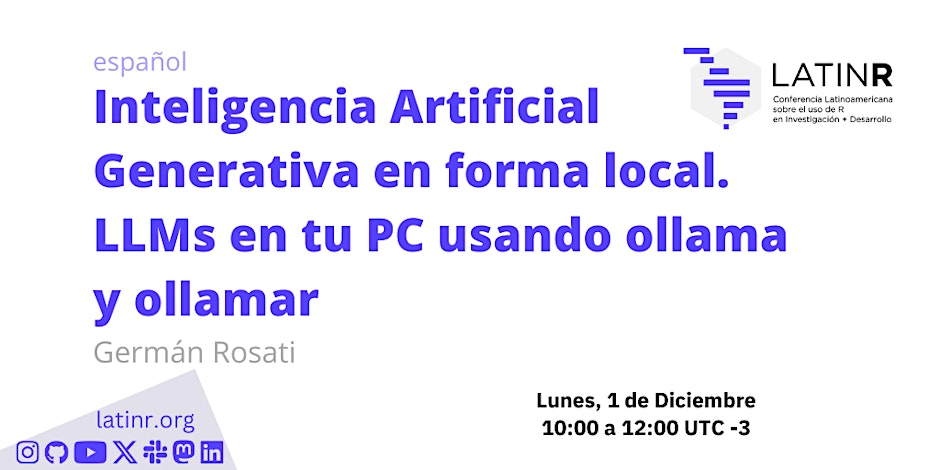


### Facilitador: [Germán Rosati](https://gefero.github.io/)

## Antes de empezar, una pequeña encuesta

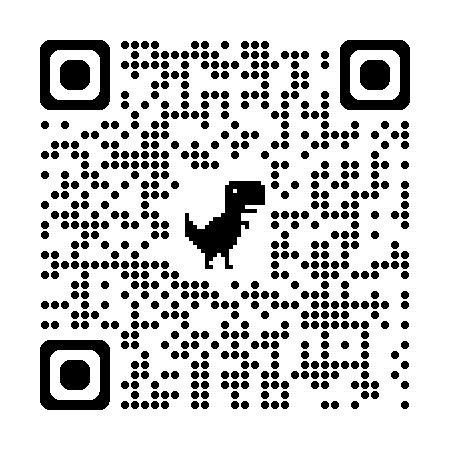


## ¿Por qué usar Ollama para trabajar con LLMs?

El ecosistema de modelos de lenguaje (LLMs) ha crecido de manera vertiginosa en los últimos años, y hoy existen múltiples formas de interactuar con estos modelos. Una de las alternativas más interesantes para quienes buscan autonomía, privacidad y eficiencia es [**Ollama**](https://ollama.com/), un framework que permite correr modelos de lenguaje de forma **local**, sin necesidad de conexión a servidores externos ni suscripciones a servicios en la nube.

<img src = https://ollama.com/public/new.png svg.png width = "500" height = "400" >

### Principales ventajas de usar Ollama

**1. Privacidad y control de los datos**
Cuando usás un LLM a través de una API (como OpenAI, Anthropic o Google), tus datos viajan a servidores externos. Aunque estas plataformas suelen ofrecer garantías de confidencialidad, en entornos sensibles —como investigación académica, periodismo, salud o proyectos empresariales— puede ser crucial evitar cualquier exposición innecesaria de la información. Con Ollama, todo el procesamiento ocurre en tu propia máquina, lo que garantiza un mayor control sobre los datos y minimiza riesgos.

**2. Cero costos por token o por uso**
Las APIs en la nube se facturan generalmente por tokens procesados, lo que puede volverse costoso a medida que se escala el proyecto o se realizan tareas más intensivas. Ollama, en cambio, permite correr modelos gratuitos (o de código abierto con licencias permisivas) directamente desde tu computadora, sin pagar por cada consulta.

**3. Funciona sin conexión a internet**
Una vez descargado el modelo, Ollama puede funcionar **completamente offline**, algo especialmente útil en contextos con conectividad limitada, situaciones de campo o ambientes aislados del entorno digital.

**4. Facilidad de uso y puesta en marcha**
Ollama ofrece una interfaz simple y consistente para correr distintos modelos (como LLaMA 3, Mistral, Phi, Gemma, entre otros), con comandos sencillos como `ollama run mistral`. Se encarga automáticamente de descargar el modelo, configurarlo y ejecutarlo, sin necesidad de configurar manualmente entornos de inferencia complejos.

**5. Acceso a modelos personalizables y de código abierto**
Con Ollama, se pueden cargar modelos open-source y **afinarlos con instrucciones o datasets propios**, permitiendo una personalización más profunda sin depender de restricciones impuestas por plataformas comerciales. Además, su integración con otras herramientas como LangChain o RAG pipelines facilita la construcción de agentes conversacionales o asistentes locales.

Además, existe un último aspecto a tener en cuenta: muchos LLMs  "más pequeños" en cantidad de parámetros presentan performaces similares a los más grandes.

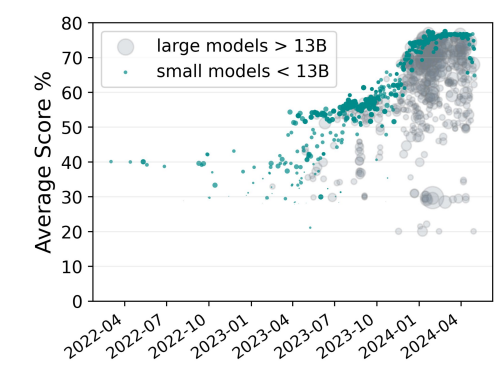


Si les interesa profundizar en está última cuestión [acá](https://www.youtube.com/watch?v=PMYhI0K_508&t=139s) hay una conferencia al respecto que dió Sara Hooker este año. [Acá](https://arxiv.org/abs/2407.05694v1), además, está el paper original del cual extrajimos el gráfico anterior.


## Un ejemplo de uso: resumiendo y analizando noticias con un LLM local

En este ejemplo, vamos a trabajar con un dataset de noticias y vamos a realizar una serie de tareas básicas de procesamiento de lenguaje natural:

- resumen
- clasificación

### Dataset
El archivo que se adjunta consiste en un corpus de unas 7.000 noticias scrapeadas entre julio y septiembre de 2019 de los siguientes medios de circulación nacional:

- Télam
- La Nación
- Clarín
- Perfil
- Infobae
- MinutoUno
- Página 12

Constituye una muestra aleatoria del corpus construido por Florencia Piñeyrúa para su tesina de grado “Procesamiento del lenguaje natural aplicado al estudio de tópicos de noticias de seguridad en Argentina: julio a septiembre 2019”. Una exposición más concentrada de sus resultados puede encontrarse en el [siguiente artículo](https://publicaciones.sociales.uba.ar/index.php/revistacomunicacion/article/view/6627/6351).

El corpus contiene, las siguientes variables:

- `id`: identificador de cada documento
- `url`: link a la noticia original
- `fecha`: fecha de publicación
- `anio`: año de publicación
- `mes`: mes de publicación
- `dia`: dia de publicación
- `medio` : medio en el que fue publicado
- `titulo`: título de la nota
- `texto`: cuerpo de la nota

### Media Bias Detector
Vamos a trabajar con algunos prompts tomados del [Media Bias Detector](https://mediabiasdetector.seas.upenn.edu/methodology/) de la Universidad de Penn. Este proyecto intenta cuantificar el llamado "sesgo informativo" —la selección preferencial de historias, hechos, personas, eventos o puntos de vista—, dado que asumen que el mismo puede ser más determinante y sutil que las mentiras deliberadas

En particular, parte de la información en una nota puede ser técnicamente verdadera, pero precisamente por eso resulta más difícil de cuestionar o desmentir

El Media Bias Detector intenta medir y exponer este sesgo en medios informativos en tiempo casi real, monitoreando una selección de medios prominentes y abarcando el espectro político.

A diferencia de otros servicios que clasifican el sesgo a nivel editorial o de medio, este herramienta analiza cada artículo individual, considerando que un mismo medio puede variar en tono o inclinación según tema, autor u otros factores.

Sin entrar en demasiado detalles, diremos que el flujo de trabajo del Media Bias Detector consiste en las siguientes etapas:

1. **Selección de medios:** Comienzan con diez importantes medios en línea de EE.UU.: Associated Press, Breitbart, CNN, Fox News, The Guardian, HuffPost, The New York Times, USA Today, The Wall Street Journal y The Washington Post
Media Bias Detector.

2. **Extracción periódica de portales:** Cada medio se revisa cinco veces al día (a las 6 a.m., 10 a.m., 2 p.m., 6 p.m. y 10 p.m. EST). Se capturan los 20 artículos más destacados según ubicación en la página, tamaño de fuente y presencia de figuras. No se procesan contenidos como videos, podcasts o galerías de fotos
Media Bias Detector.

3. **Obtención de contenido:** Se extraen el texto del artículo, el título y la fecha de publicación.

4. **Preprocesamiento del texto:** Se eliminan elementos irrelevantes como anuncios, menciones al medio fuera del contexto, frases repetitivas (p. ej. “Escucha 5 minutos”, “Haz clic aquí para más información”). Se sigue ampliando el diccionario para limpiar estos elementos automáticamente.

Por último, el texto se clasifica mediante usando GPT mediante una serie de prompts que pueden encontrarse en este link.

**Esquema del proceso del Media Bias Detector**

<img src = https://mediabiasdetector.seas.upenn.edu/assets/images/pipeline.png width = "800" height = "400" >

Vamos a intentar replicar algunos ejercicios de clasificación de texto que se hacen en este programa. Pero lo vamos a hacer local, gratis y (esperamos) bien.


### Ollama
Pero primero tenemos que instalar `Ollama`. En este tutorial vamos a hacer la instalación en Linux, pero en caso de que usen otro sistema operativo, acá les dejamos algunos links útiles.

**Windows**
- [instalador](https://ollama.com/download/windows)
- [tutorial en video](https://www.youtube.com/watch?v=3W-trR0ROUY)

**Mac**
- [instalador](https://ollama.com/download/mac)
- [tutorial en video](https://www.youtube.com/watch?v=Og7B1bw-h_0)

Bueno, listo. Vamos a lo nuestro.

### 1. Instalación

Lo primero que tenemos que hacer es descargar Ollama:

In [ ]:
system("curl -fsSL https://ollama.com/install.sh | sh")

Luego, tenemos que instalar algunos paquetes que nos permitan usar ollama desde R:

In [ ]:
install.packages("ollamar")
install.packages("jsonlite")
install.packages("tictoc")

## Activamos el server de ollama
En esta parte tenemos que abrir la terminal (en Google Colab está abajo a la izquierda). Si están usando Windowos o Mac, abran la consola que corresponda.

Luego, tipeamos los siguientes comandos en la terminal:

`ollama serve &` # iniciamos el server

`ollama run "gemma3:1b"` # corremos y activamos [Gemma](https://ollama.com/library/gemma3) de 1 miles de millones de parámetros




## Carga de paquetes

In [ ]:
library(ollamar)
library(tidyverse)
library(jsonlite)

## Carga de datos

### Opción 1: Subir tu propio archivo CSV
Ejecuta la siguiente celda para subir tu propio archivo CSV. El archivo debe tener una columna llamada `texto` con el contenido de los artículos.

In [ ]:
%%python
from google.colab import files
import os

print("Selecciona un archivo CSV para subir:")
uploaded = files.upload()

if uploaded and len(uploaded) > 0:
    uploaded_filename = list(uploaded.keys())[0]
    # Mover el archivo a /content/ con un nombre conocido
    os.rename(uploaded_filename, '/content/uploaded_data.csv')
    print(f"Archivo '{uploaded_filename}' subido exitosamente como '/content/uploaded_data.csv'")
else:
    print("No se subió ningún archivo. Usa la Opción 2 para usar el dataset de ejemplo.")

### Opción 2: Usar el dataset de ejemplo
Si prefieres usar el dataset de ejemplo, ejecuta la siguiente celda para clonar el repositorio con los datos.

In [ ]:
# Clonar el repositorio con los datos
system("git clone https://github.com/gefero/factor_data_tutorial_local_LLMs.git")

### Cargar los datos
Ejecuta la siguiente celda para cargar los datos. Si subiste tu propio archivo, se usará ese. Si no, se usará el dataset de ejemplo.

In [ ]:
# Verificar si existe el archivo subido, si no, usar el del repositorio clonado
if (file.exists('/content/uploaded_data.csv')) {
  df <- read_csv('/content/uploaded_data.csv')
  cat("Usando el archivo subido: /content/uploaded_data.csv\n")
} else {
  df <- read_csv('/content/factor_data_tutorial_local_LLMs/data/corpus_medios.csv')
  cat("Usando el dataset de ejemplo del repositorio clonado.\n")
}

# Crear una muestra aleatoria de diez documentos
set.seed(789) # para reproducibilidad
df_sample <- sample_n(df, 10)

head(df_sample)

## Diseño de prompts
### Castellano

In [ ]:
system_prompt_es <- "Sos un investigador experto en medios de comunicación digitales y noticias."

prompt_resumen_es <- "
  El siguiente es un artículo de noticias. Léelo y realiza la tarea que se indica a continuación. Responde con un objeto JSON de pares clave-valor.

  ####################

  {article}

  ####################

  Tarea: Resume los puntos principales del artículo de noticias.

  Instrucción: Enumera puntos clave cortos que los lectores probablemente recordarán del artículo.
  Clave: \"takeaways\"
  Valor: Un resumen de 3-4 frases en formato de lista JSON."

prompt_tipo_noticia_es <- "El siguiente es un artículo de noticias. Léelo y realiza la tarea que se indica a continuación.


####################


{article}


####################


Tarea: Determina el tipo de noticia de este artículo.Responde con un objeto JSON de pares clave-valor.

1. Instrucción: Clasifica el artículo de noticias anterior en una de tres categorías: reportaje de noticias, análisis de noticias u opinión. Cada categoría tiene características distintas:

- Noticia: Reportaje objetivo sobre eventos recientes, centrado en hechos verificados sin los puntos de vista personales del escritor.
- Análisis: Examen e interpretación en profundidad de eventos noticiosos, proporcionando contexto y explicando su significado, manteniendo un grado de objetividad.
- Opinión: Artículos que reflejan puntos de vista personales, argumentos o creencias sobre temas actuales, a menudo persuasivos y subjetivos.

Considera criterios como la objetividad del lenguaje, el enfoque en hechos versus interpretación, la intención del autor y la estructura del artículo.

Clave: \"news_type\"
Valor: Uno de \"noticia\", \"análisis \" u \"opinión\".


2. Instrucción: Proporciona un párrafo corto para justificar tu clasificación, citando elementos específicos del texto.
Clave: \"justification\"
Valor: Un párrafo de texto.


No devuelvas nada excepto el texto."

prompt_tone_es <- "El siguiente es un artículo de noticias. Léelo y realiza la tarea que se indica a continuación. Responde con un objeto JSON de pares clave-valor.

####################

{article}

####################

Tarea: Determina el tono general del artículo. ¿Es negativo, positivo o neutral?



1. Instrucción: Proporciona un párrafo largo y detallado para justificar tu clasificación, citando elementos específicos del texto.
Clave: \"justification\"
Valor: Un párrafo de texto.

2. Instrucción: Proporciona un número del -5 al 5, donde -5 indica un tono muy negativo y 5 indica un tono muy positivo. Un valor de 0 indica que el artículo tiene un tono neutral.
Clave: \"tone\"
Valor: Un número entero del -5 al 5.

No devuelvas nada excepto el texto."


### Inglés (por si les interesa ver los prompts originales)

In [ ]:
system_prompt <- "You are an expert researcher in news and digital media."

prompt_resumen <- "
  The following is a news article. Read it and perform the task that follows. Respond with a JSON object of key-value pairs.

  ####################

  {article}

  ####################

  Task: Summarize the main points of the news article.

  Instruction: List short takeaway points that readers are likely to remember from the article.
  Key: \"takeaways\"
  Value: A 3-4 sentence summary in a JSON list format.

"

prompt_tipo_noticia <- "
The following is a news article. Read it and perform the task that follows. Respond with a JSON object of key-value pairs.


####################


{article}


####################


Task: Determine the news type of this news article.


1. Instruction: Classify the above news article into one of three categories: news report, news analysis, or opinion. Each category has distinct characteristics:
- News Report: Objective reporting on recent events, focusing on verified facts without the writer's personal views.
- News Analysis: In-depth examination and interpretation of news events, providing context and explaining significance, while maintaining a degree of objectivity.
- Opinion: Articles reflecting personal views, arguments, or beliefs on current issues, often persuasive and subjective.
Consider criteria such as language objectivity, focus on facts versus interpretation, author's intent, and article structure.
Key: \"news_type\"
Value: One of \"news report\" or \"news analysis\" or \"opinion\".


2. Instruction: Provide a short paragraph to justify your classification, citing specific elements from the text.
Key: \"justification\"
Value: A paragraph of text.


Do not return anything except the JSON object of key-value pairs as outpu
"

prompt_tone <- "
The following is a news article. Read it and perform the task that follows. Respond with a JSON object of key-value pairs.


####################


{article}


####################


Task: Determine the overall tone of the article. Is it negative, positive, or neutral?


1. Instruction: Provide a short paragraph summarizing in what ways the article has a negative or positive tone.
   Key: \"reason\"
   Value: A paragraph of text.


2. Instruction: Provide a number from -5 to 5, with -5 indicating a very negative tone and 5 indicating a very positive tone. A value of 0 indicates that the article has a neutral tone.
   Key: \"tone\"
   Value: An integer number from -5 to 5.


Do not return anything except the JSON object of key-value pairs as output.
"

Construyamos el prompt...

In [ ]:
# Función para construir el prompt
build_prompt <- function(article, tipo_prompt) {
  stringr::str_replace(tipo_prompt, "\\{article\\}", article)
}

 La función `build_prompt` es una función auxiliar muy sencilla que se encarga de construir el prompt completo que se le enviará al modelo de Ollama.

1. Toma dos argumentos:
  - `article`: El texto del artículo de noticias que quieres procesar.
  - `tipo_prompt`: Una plantilla de prompt predefinida (como `prompt_tipo_noticia` o `prompt_resumen`).

2. Formatea el prompt: Utiliza la función `str_replace()` para insertar el texto del `article` dentro de la plantilla `tipo_prompt` en el lugar especificado por `{article}`.

3. Devuelve el prompt completo: El resultado es una cadena de texto que contiene tanto las instrucciones para el modelo como el texto del artículo, listo para ser enviado a la función `ollama.chat`.

En esencia, esta función permite reutilizar las plantillas de prompt y simplemente pasarle el texto del artículo para que el modelo procese.

## El caso más simple...

Clasifiquemos una noticia y analicemos el código para un caso particular. Esto nos va a permitir, luego, extender esto a todo el corpus.

In [ ]:
mod <- "gemma3:1b"

art <- df %>% slice(5) %>% select(texto) %>% pull()
prpt <- build_prompt(art, prompt_tone_es)

Veamos cómo quedó el prpt (nuestro prompt):

In [ ]:
cat(prpt)

Ahora, genermos, el objeto que va a tener el prompt "usuario" y el prompt de "sistema". Básicamente, generamos una "lista" de "listas"... una lista por cada rol.

In [ ]:
msgs <- list(
    list(role = "system", content = system_prompt_es), # Usar el system_prompt_es definido en R
    list(role = "user", content = prpt)
  )

  msgs

Ahora estamos en condiciones de hacer nuestra primera consulta al LLM local:

In [ ]:
rsp <- ollamar::chat(
    model = mod,
    messages = msgs,
    temperature = 1.0
  )

Este fragmento de código utiliza la función `chat` del paquete `ollamar` en R para interactuar con un modelo de lenguaje local que se ejecuta a través de Ollama. Aquí te explico cada parte:

*   `rsp <- ollamar::chat(...)`: Asigna el resultado de la llamada a la función `chat` a la variable `rsp`. Este objeto `rsp` contendrá la respuesta completa del modelo.
*   `model = mod`: Especifica el nombre del modelo de Ollama que se utilizará para generar la respuesta. La variable `mod` debería contener una cadena de texto con el nombre del modelo, como por ejemplo `"deepseek-r1:1.5b"`.
*   `messages = msgs`: Proporciona el historial de la conversación al modelo. `msgs` es una lista de listas, donde cada sublista representa un mensaje con un `role` (como `"system"` o `"user"`) y el `content` del mensaje. Esto es fundamental para que el modelo entienda el contexto de la conversación.
*   `temperature = 1.0`: Controla la creatividad o aleatoriedad de la respuesta del modelo. Un valor de 1.0 es un valor por defecto que permite cierta variabilidad. Valores más bajos (cercanos a 0) harán la respuesta más determinística, mientras que valores más altos (mayores a 1.0) la harán más aleatoria.
* Hay otros parámetros que usaremos enseguida.

El resultado de esta interacción se almacena en la variable `rsp`.

In [ ]:
rsp

Como puede verse, `rsp` es un objeto raro. Se llama `httr2_response` y es lo que se obtiene al hacer una solicitud HTTP a la API de Ollama. Contiene toda la información de la respuesta del servidor, como el estado (por ejemplo, 200 OK), los encabezados, y el cuerpo de la respuesta.

Para obtener el contenido real generado por el modelo de lenguaje (el texto o JSON), necesitas procesar este objeto `httr2_response`. La función `resp_process()` del paquete ollamar es la encargada de extraer el contenido útil del cuerpo de la respuesta.

In [ ]:
resp_process(rsp)

Por defecto, `resp_process()`devuelve un `data.frame` con varias columnas:

- `model`
- `role`
- `content`: Esta es la que nos interesa
- `created_at`

Hay varios tipos de output que podemos pedirle a la función. Por ejemplo, podemos pedirle que nos devuelva un objeto `character`.

In [ ]:
resp_process(rsp, "text")

Pueden investigar [qué otros formatos hay disponbibles](https://hauselin.github.io/ollama-r/reference/resp_process.html).


Volvamos a nuestro `data.frame`. La columna `content` tiene la respuesta del LLM. Veamos qué tiene adentro. Empieza con un texto bastante largo encerrado entre un token `<think>` y otro `<\think>`. En lugar de responder directamente, el modelo primero "piensa en voz alta" a través de un proceso de razonamiento estructurado. En muchos casos, esto significa aplicar un enfoque de cadena de pensamiento : el modelo descompone el problema en pasos y escribe cada paso antes de dar el resultado final. Por ejemplo, la documentación de Ollama sugiere que los modelos compatibles generarán algo como bloques <think>…</think> para capturar su razonamiento. Esto es análogo a indicarle a una IA que "muestre su trabajo" en un problema de matemáticas o que "resuma su razonamiento" en un debate, excepto que Ollama lo automatiza.

En este caso, y solo a los efectos de este notebook, vamos a dejar al "monólogo interno" fuera de nuestro análisis. Tenemos que "limpiarlo" de la columna `content`. Para eso, generamos esta función:

In [ ]:
parse_response <- function(resp){
  resp_process(resp) %>%
  select(content) %>%
  pull() %>%
  sub('.*</think>', '', .) %>%
  stringr::str_replace_all("```json|```", "")   %>%
  fromJSON()
  as_tibble()
}

La función `parse_response` toma el objeto de respuesta cruda (`httr2_response`) obtenido de `ollamar::chat` y lo procesa para extraer y limpiar el contenido generado por el modelo, devolviendo un data frame con la información parseada. Aquí te explico cada paso:

1.  **`resp_process(resp)`**: Esta es la primera función que se aplica. Toma el objeto `httr2_response` (`resp`) y extrae el contenido del cuerpo de la respuesta. Por defecto, `resp_process()` devuelve un data frame con columnas como `model`, `role`, `content`, y `created_at`. La columna `content` es la que contiene el texto generado por el LLM, que puede incluir el "pensamiento en voz alta" del modelo (`<think>...</think>`) y el bloque JSON.

2.  **`select(content)`**: Después de `resp_process()`, se utiliza `select()` (probablemente del paquete `dplyr`, parte del `tidyverse` que se cargó anteriormente) para seleccionar únicamente la columna `content` del data frame resultante. Esto aísla el texto generado por el modelo.

3.  **`pull()`**: Esta función (también de `dplyr`) toma la columna seleccionada (`content`) y la extrae como un vector. Esto es útil porque las siguientes operaciones de manipulación de texto (`sub`, `stringr::str_replace_all`, `fromJSON`) operan mejor sobre un vector de caracteres.

4.  **`sub('.*</think>', '', .)`**: Aquí comienza la limpieza del texto. `sub()` realiza sustituciones de texto. En este caso:
    *   `'.*</think>'`: Este es el patrón a buscar. `.` coincide con cualquier carácter (excepto una nueva línea), `*` coincide con cero o más de esos caracteres, y `</think>` coincide literalmente con el token de cierre. `.*</think>` coincide con cualquier cosa desde el inicio del string hasta la primera aparición de `</think>`.
    *   `''`: Este es el texto con el que se reemplazará el patrón encontrado. Es una cadena vacía, lo que significa que se eliminará la parte que coincide con el patrón.
    *   `.`: Esto indica que la sustitución se aplicará al resultado del paso anterior en la cadena de operaciones (el vector de texto).
    *   **Propósito**: Este paso elimina el token de "pensamiento" inicial del modelo y todo lo que lo precede.

5.  **`stringr::str_replace_all("```json|```", "")`**: Esta función (del paquete `stringr`, también parte del `tidyverse`) realiza sustituciones de texto.
    *   `"```json|```"`: Este es el patrón a buscar. Es una expresión regular que busca ````json` O (`|`) `````.
    *   `""`: Este es el texto con el que se reemplazará el patrón encontrado. Es una cadena vacía, lo que significa que se eliminarán los marcadores de bloque de código JSON.
    *   **Propósito**: Este paso elimina los marcadores ````json` y ````` que a menudo envuelven el bloque JSON generado por el modelo.

6.  **`fromJSON()`**: Esta función (del paquete `jsonlite`) toma el string de caracteres resultante (que ahora debería ser un JSON válido) y lo parsea en una estructura de datos de R. Si el JSON representa un objeto (con pares clave-valor), `fromJSON` por defecto intentará convertirlo en un data frame si es posible, o en una lista si no.

7.  **`as_data_frame()`**: Esta función (también de `dplyr`) se asegura de que el resultado del parseo JSON sea un data frame. Si `fromJSON` ya devolvió un data frame, esto no hará nada. Si devolvió una lista (por ejemplo, si el JSON de nivel superior era una lista de objetos), intentará convertir esa lista en un data frame.

En resumen, `parse_response` va desde la respuesta cruda de la API de Ollama, extrae el texto relevante, limpia los marcadores de pensamiento y los delimitadores de JSON, y finalmente parsea el string JSON limpio a un data frame de R para facilitar su manipulación y análisis posterior.

In [ ]:
parse_response(rsp)


Sin embargo, esto puede fallar. Por eso, suele ser mejor, en caso de que la salida que solicitemos pueda ser estructurada definir de forma programática el formato de salida.

## Salidas estructuradas

Podemos definir la estructura esperada usando listas o data frames. Para este caso, simplemente documentaremos la estructura esperada basada en los prompts que solicitan JSON.

**- Estructura esperada para el tipo de noticia:** `list(news_type = list(type="string"), justification = list(type="string")`

**- Estructura esperada para el resumen:** `list(takeaways = list(type="string")`

**- Estructura esperada para el tono::** `list(reason = list(type="string", tone = list(type="integer")`

No necesitamos código ejecutable aquí, ya que el paquete 'ollamar' maneja la salida JSON directamente. Las definiciones de prompts ya solicitan el formato JSON.

In [ ]:
# define a schema as a list to constrain a model's output
format_tipo_noticia <- list(
  type = "object",
  properties = list(
    news_type = list(type = "string"),
    justification = list(type = "string")
    ),
  required = list("news_type", "justification")
  )

format_tone <- list(
  type = "object",
  properties = list(
    tone = list(type = "integer"),
    justification = list(type = "string")
    ),
  required = list("tone", "justification")
  )

In [ ]:
 rsp_format <- ollamar::chat(
    model = mod,
    messages = msgs,
    temperature = 1.0,
    format=format_tipo_noticia,
    output="structured"
  )

  rsp_format

## Escalando la cosa

Queremos, ahora, aplicar este procedimiento a todo el corpus. Podríamos, para poder reutilizar mejor el código anterior, encapsularlo todo en una función que podamos llamar para cada artículo:

In [ ]:
# Función para obtener respuesta de Ollama
get_ollama_response <- function(article, prompt_type, prompt_format, model) { # Removed format_schema as it's not used
  prompt <- build_prompt(article, prompt_type)

  # Construir el mensaje para ollamar
  messages <- list(
    list(role = "system", content = system_prompt_es), # Usar el system_prompt_es definido en R
    list(role = "user", content = prompt)
  )

  # Obtener la respuesta del modelo
  response <- ollamar::chat(
    model = model,
    messages = messages,
    temperature = 1.0,
    output="structured",
    format=prompt_format
    )

  # Transformamos la sli
  resp_df <- response %>% as_tibble()

  # Agregar un pequeño retraso para evitar sobrecargar el servidor Ollama (opcional pero recomendado)
  Sys.sleep(5)

  return(resp_df)
}

La función se utiliza para enviar un artículo de noticias a un modelo de lenguaje local de Ollama, aplicar un prompt específico y obtener una respuesta estructurada. Tiene los siguientes parámetros:

*   **`article`** (`character`): Este parámetro espera una cadena de texto que contiene el cuerpo completo del artículo de noticias que deseas que el modelo procese.
*   **`prompt_type`** (`character`): Una cadena de texto que representa la plantilla del prompt que se aplicará al artículo (por ejemplo, `prompt_resumen_es`, `prompt_tipo_noticia_es`, `prompt_tone_es`). Esta plantilla contiene las instrucciones para el modelo y un marcador (`{article}`) donde se insertará el texto del artículo.
*   **`prompt_format`** (`list`): Una lista que define el esquema JSON esperado para la respuesta del modelo. Este esquema se utiliza con el parámetro `output="structured"` en la función `ollamar::chat` para guiar al modelo a generar una respuesta en un formato JSON específico (como `format_tone` o `format_tipo_noticia`).
*   **`model`** (`character`): Una cadena de texto que especifica el nombre del modelo de Ollama que se utilizará para procesar el artículo (por ejemplo, `"deepseek-r1:1.5b"`). Este modelo debe estar descargado y disponible en tu instancia de Ollama.

**¿Cómo funciona y qupe hace?**

1.  *Construcción del Prompt:* La función `build_prompt` (definida previamente) se llama para combinar el texto del `article` con la plantilla `prompt_type`, creando el prompt completo que se enviará al modelo.
2.  *Estructuración de Mensajes:* Se crea una lista llamada `messages` que sigue el formato de conversación esperado por la API de Ollama. Incluye un mensaje con el rol `"system"` (utilizando el `system_prompt_es` para definir el comportamiento del modelo) y otro mensaje con el rol `"user"` que contiene el prompt construido.
3.  *Llamada a Ollama:* Se utiliza la función `ollamar::chat` del paquete `ollamar` para enviar la solicitud al servidor de Ollama.
    *   Se especifica el `model` a utilizar.
    *   Se pasan los `messages` que contienen la conversación.
    *   `temperature = 1.0` controla la creatividad de la respuesta.
    *   `output = "structured"` indica a Ollama que intente devolver la respuesta en el formato estructurado especificado.
    *   `format = prompt_format` proporciona el esquema JSON que define la estructura esperada de la respuesta.
4.  *Procesamiento de la Respuesta:* La respuesta cruda obtenida de `ollamar::chat` (que es un objeto `httr2_response`) se convierte en un `tibble` utilizando el operador pipe (`%>%`) y la función `as_tibble()`. Esto hace que la respuesta sea más fácil de manejar en R.
5.  *Retraso:* `Sys.sleep(5)` pausa la ejecución por 5 segundos. Esto es una buena práctica para evitar sobrecargar el servidor de Ollama con demasiadas solicitudes consecutivas, especialmente cuando se procesan múltiples elementos en un bucle.
6.  *Retorno del Resultado:* Finalmente, la función devuelve el `tibble` (`resp_df`) que contiene la respuesta procesada del modelo de Ollama. Esta respuesta debería estar en el formato estructurado especificado por `prompt_format`.

In [ ]:
responses_df <- tibble(
  url = character(),
  news_type = character(),
  justification = character()
)

tictoc::tic()
for (i in 1:nrow(df_sample)){

  df_s <- df_sample %>% slice(i)
  article <- df_s %>% select(texto) %>% pull()
  ur <- df_s %>% select(url) %>% pull()

  resp_df <- get_ollama_response(article,
                               prompt_type=prompt_tipo_noticia_es,
                               prompt_format=format_tipo_noticia,
                               model=mod)

  resp_df <- resp_df %>%
    mutate(url = ur) %>%
    select(url, everything())


  responses_df <- responses_df %>% bind_rows(resp_df)
}
tictoc::toc()

Este bloque de código tiene como objetivo procesar cada artículo en el df_sample utilizando el modelo de Ollama para clasificar el tipo de noticia y obtener una justificación, almacenando los resultados en un nuevo data frame llamado responses_df.

**Paso 1: Inicialización del DataFrame para almacenar respuestas**

```r
responses_df <- tibble(
  url = character(),
  news_type = character(),
  justification = character()
)
```
Se crea un data frame vacío llamado `responses_df` usando la función `tibble()` del paquete `tibble` (parte del `tidyverse`). Se definen las columnas esperadas (`url`, `news_type`, `justification`) con tipos de datos iniciales (`character()` indica que son columnas de texto vacías). Este data frame se utilizará para almacenar los resultados obtenidos de cada artículo procesado.

**Paso 2: Iniciar el cronómetro**

```r
tictoc::tic()
```

Se utiliza la función `tic()` del paquete `tictoc` para iniciar un cronómetro. Esto permitirá medir cuánto tiempo tarda en ejecutarse el bucle que procesa todos los artículos.

**Paso 3: Iniciar el bucle para iterar sobre los artículos`

```r
for (i in 1:nrow(df_sample)){
  # Código dentro del bucle
}
```

Se inicia un loop `for` que recorrerá cada fila del data frame `df_sample`. `nrow(df_sample)` devuelve el número total de filas en df_sample, por lo que el bucle se ejecutará una vez por cada artículo en la muestra. En cada iteración, la variable i tomará el valor del índice de la fila actual (desde 1 hasta el número total de filas).

**Paso 4: Seleccionar el artículo actual y su URL**

```r
  df_s <- df_sample %>% slice(i)
  article <- df_s %>% select(texto) %>% pull()
  ur <- df_s %>% select(url) %>% pull()
```

Dentro del bucle, estas líneas seleccionan los datos de la fila actual (`i`):

- `df_sample %>% slice(i):` Selecciona la i-ésima fila de `df_sample` y la guarda en un pequeño data frame llamado `df_s`.

- `df_s %>% select(texto) %>% pull()`: De la fila seleccionada (`df_s`), selecciona la columna texto y extrae su contenido como un vector de caracteres (en este caso, será un vector con un solo elemento, el texto del artículo). Este texto se guarda en la variable `article`.

- `df_s %>% select(url) %>% pull()`: De manera similar, selecciona la columna `url` de la fila actual y extrae su contenido, guardándolo en la variable `ur`.

**Paso 5: Obtener la respuesta del modelo de Ollama**

```r
  resp_df <- get_ollama_response(article, prompt_tipo_noticia_es, format_tipo_noticia, mod)
```

Se llama a la función `get_ollama_response` (definida en una celda anterior) con los siguientes argumentos:

- `article`: El texto del artículo actual.
- `prompt_tipo_noticia_es`: La plantilla del prompt en español para clasificar el tipo de noticia.
- `format_tipo_noticia`: El esquema JSON que define el formato estructurado esperado para la respuesta de clasificación.
- `mod`: El nombre del modelo de Ollama a utilizar (definido previamente, por ejemplo, "deepseek-r1:1.5b").

La función `get_ollama_response` se encarga de enviar esta información al modelo de Ollama, obtener la respuesta estructurada (el tipo de noticia y la justificación) y devolverla como un tibble. Este tibble se almacena en la variable `resp_df`.

**Paso 6: Agregar la URL al data frame de respuesta del artículo actual**

```r
  resp_df <- resp_df %>%
    mutate(url = ur) %>%
    select(url, everything())
```

Se modifica el tibble `resp_df` (que contiene la clasificación y justificación del artículo actual) para agregar la URL del artículo:

- `mutate(url = ur)`: Crea una nueva columna llamada `url` en `resp_df` y le asigna el valor de la variable `ur` (la URL del artículo actual).

- `select(url, everything())`: Reorganiza las columnas en `resp_df` para que la columna `url` sea la primera, seguida de todas las demás columnas (`everything()`). Esto asegura que el data frame de respuesta tenga la misma estructura que el `responses_df` principal.

**Paso 7: Añadir la respuesta del artículo actual al data frame principal**


```r
  responses_df <- responses_df %>% bind_rows(resp_df)
```

Se utiliza la función `bind_rows()` del paquete `dplyr` para añadir las filas del tibble `resp_df` (que contiene el resultado del artículo actual) al final del data frame `responses_df`. En cada iteración, el resultado de un artículo se añade a la colección total de respuestas.

***Paso 8: Finalizar el cronómetro**

```r
tictoc::toc()
```

Después de que el bucle ha terminado de procesar todos los artículos, se llama a la función `toc()` del paquete tictoc para detener el cronómetro e imprimir el tiempo total que tomó la ejecución del bucle.

En resumen, este bucle recorre cada artículo de la muestra, llama a la función para obtener la clasificación del modelo de Ollama, añade la URL al resultado y acumula los resultados en un data frame central (`responses_df`) para su posterior análisis.



In [ ]:
responses_df

## Ejercitacion 1
Pueden ir al sitio de [ollama](https://ollama.com/), buscar entre [los modelos disponibles](https://ollama.com/search), elegir otro modelo y repetir la tarea de clasificación de tipos de noticias. ¿Cuál les parece que funcionó mejor?

## Ejercitación 2
Ahora, ustedes generen un resumen de cada artículo en `df_sample` (recuerden pensar y definir un formato para una respuesta estructurada):

## Ejercitación 3
Usen el prompt correspondiente a la detección de tono y pídanle a `gemma` que realice una clasificación del tono de la muestra del corpus.